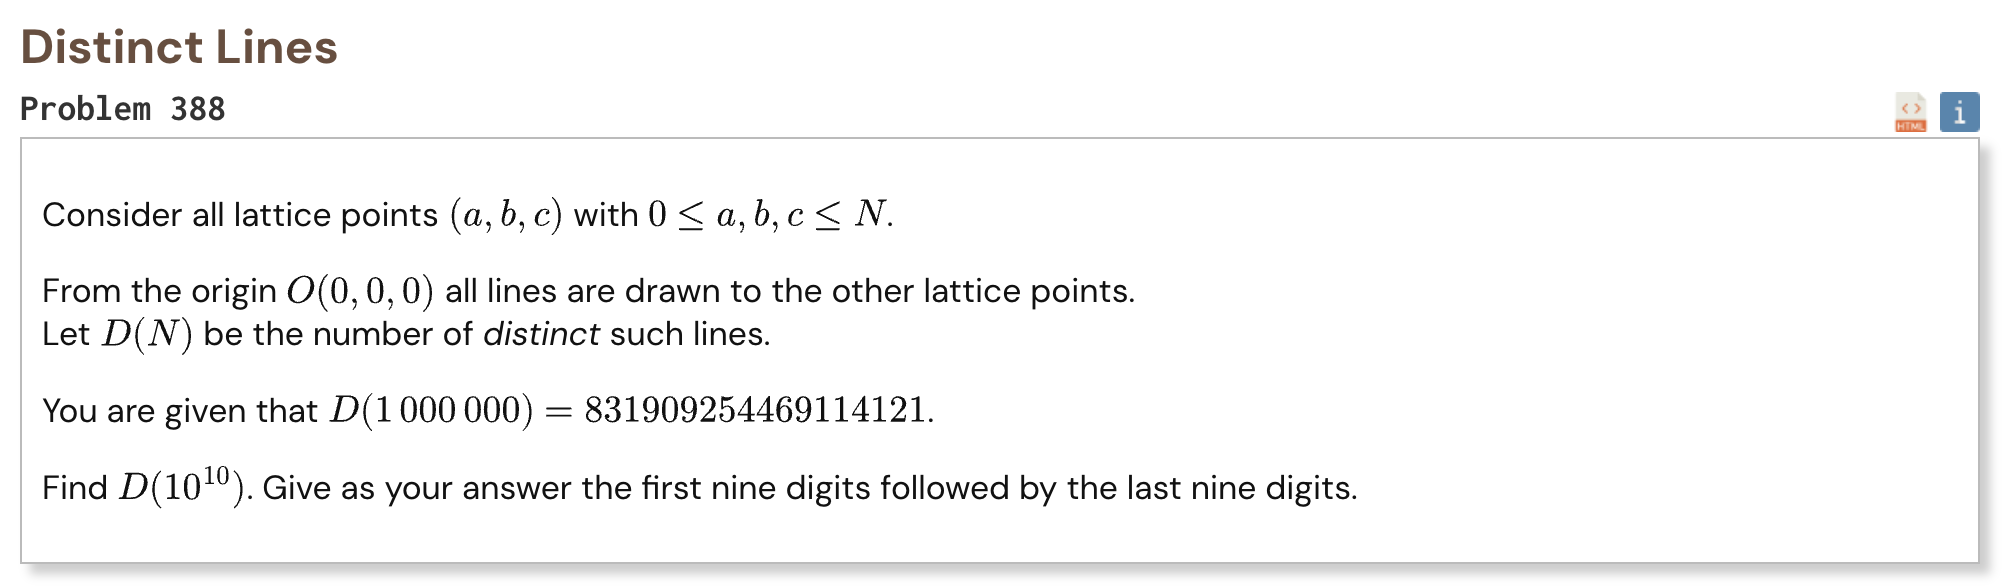

## Initial approach

* each line is represented by one primitive direction where gcd of the three coordinates is 1
* use Möbius inversion to count primitive triples without checking every lattice point
* for each divisor d count all nonzero points whose coordinates are divisible by d
* group consecutive divisors that produce the same value of n divided by
* calculate large Möbius prefix sums with a memoized Mertens function
* use array to store the sieve values with much less memory than normal Python lists
* verify the method using the given value for one million
* join the first nine and last nine digits of the final number

In [1]:
from array import array


def integer_cube_root(n):
    x = 1 << ((n.bit_length() + 2) // 3)

    while True:
        y = (2 * x + n // (x * x)) // 3

        if y >= x:
            while (x + 1) ** 3 <= n:
                x += 1

            while x ** 3 > n:
                x -= 1

            return x

        x = y


def mobius_prefix(limit):
    mu = array("b", [0]) * (limit + 1)
    lowest_prime = array("I", [0]) * (limit + 1)
    prefix = array("i", [0]) * (limit + 1)
    primes = []

    mu[1] = 1

    for value in range(2, limit + 1):
        if lowest_prime[value] == 0:
            lowest_prime[value] = value
            primes.append(value)
            mu[value] = -1

        for prime in primes:
            product = value * prime

            if product > limit:
                break

            lowest_prime[product] = prime

            if value % prime == 0:
                mu[product] = 0
                break

            mu[product] = -mu[value]

    total = 0

    for value in range(1, limit + 1):
        total += mu[value]
        prefix[value] = total

    return prefix


def lattice_point_count(size):
    return (size + 1) ** 3 - 1


def solve(n):
    limit = integer_cube_root(n * n)
    prefix = mobius_prefix(limit)
    cache = {}

    def mertens(value):
        if value <= limit:
            return prefix[value]

        if value in cache:
            return cache[value]

        total = 1
        left = 2

        while left <= value:
            quotient = value // left
            right = value // quotient
            total -= (right - left + 1) * mertens(quotient)
            left = right + 1

        cache[value] = total
        return total

    mertens(n)

    total = 0
    left = 1

    while left <= limit:
        quotient = n // left
        right = min(limit, n // quotient)

        mobius_sum = prefix[right] - prefix[left - 1]
        total += mobius_sum * lattice_point_count(quotient)

        left = right + 1

    maximum_quotient = n // (limit + 1)

    for quotient in range(1, maximum_quotient + 1):
        left = max(limit + 1, n // (quotient + 1) + 1)
        right = n // quotient

        if left <= right:
            mobius_sum = mertens(right) - mertens(left - 1)
            total += mobius_sum * lattice_point_count(quotient)

    return total

In [2]:
%%time
assert solve(1_000_000) == 831909254469114121
value = solve(10_000_000_000)
text = str(value)
result = text[:9] + text[-9:]
print("Result:", result)

Result: 831907372805129931
CPU times: user 5.22 s, sys: 44.2 ms, total: 5.26 s
Wall time: 5.26 s
